# Feature representations of a single heart sound recording

Walks one recording through the pipeline and plots the three feature domains
side by side, using the project's own extractors so that what you see here is
exactly what phase 02 produces.

**Sections**

1. Setup and configuration
2. Load and preprocess one recording
3. Cut it into windows
4. log-Mel — the representation that keeps time
5. MFCC — cepstrum, deltas, and what pooling destroys
6. PWP — wavelet packet bands and their descriptors
7. All three side by side
8. Cardiac-cycle context

Run from the repository root, or set `PROJECT_ROOT` below.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "src").is_dir() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
print("project root:", PROJECT_ROOT)

import numpy as np
import matplotlib.pyplot as plt

from src.config.loader import load_config
from src.data.loader import load_audio
from src.data.preprocessing import preprocess_recording
from src.data.segmentation import segment_signal
from src.features.mfcc import MFCCExtractor
from src.features.logmel import LogMelExtractor
from src.features.pwp import PWPExtractor
from src.xai.segmenter import segment_cardiac_cycle, STATE_NAMES

cfg = load_config(PROJECT_ROOT / "configs" / "config.yaml", project_root=PROJECT_ROOT)
SR = int(cfg["preprocessing"]["target_sr"])
FEAT = cfg["features"]

print(f"sr = {SR} Hz   n_fft = {FEAT['n_fft']}   hop = {FEAT['hop_length']}   n_mels = {FEAT['n_mels']}")

project root: c:\Users\ilyas\Desktop\UNIMI\MAGISTRALE\ANNO II\Audio Pattern Recognition\apr-heart-sounds
sr = 2000 Hz   n_fft = 256   hop = 32   n_mels = 32


The two numbers that constrain everything downstream:

In [2]:
bin_width = SR / FEAT["n_fft"]
usable_bins = (FEAT["fmax"] - FEAT["fmin"]) / bin_width
frame_ms = 1000 * FEAT["n_fft"] / SR
hop_ms   = 1000 * FEAT["hop_length"] / SR

print(f"FFT bin width      {bin_width:.2f} Hz")
print(f"usable bins in band ~{usable_bins:.0f}   (so {FEAT['n_mels']} mel filters is safe, 64 would not be)")
print(f"analysis frame     {frame_ms:.0f} ms, hop {hop_ms:.0f} ms  ->  {100*(1-FEAT['hop_length']/FEAT['n_fft']):.0f}% overlap")

FFT bin width      7.81 Hz
usable bins in band ~48   (so 32 mel filters is safe, 64 would not be)
analysis frame     128 ms, hop 16 ms  ->  88% overlap


## 2. Load and preprocess one recording

Point `WAV` at any file in `data/raw/physionet2016/`. `preprocess_recording`
runs the full chain: DC removal, resample, zero-phase band-pass, spike removal,
per-recording z-normalisation.

In [4]:
RAW = PROJECT_ROOT / "data" / "raw" / "physionet2016"

candidates = sorted(RAW.glob("training-*/*.wav"))
if not candidates:
    raise FileNotFoundError(f"No .wav found under {RAW}. Run scripts/00_download_data.py first.")

WAV = candidates[0]          # <-- change this to inspect a different recording
print(f"{len(candidates)} recordings available; using {WAV.parent.name}/{WAV.name}")

raw, sr_in = load_audio(WAV)
sig, meta = preprocess_recording(raw, sr_in, cfg["preprocessing"])

print(f"\nin : {len(raw):>7d} samples @ {sr_in} Hz")
print(f"out: {len(sig):>7d} samples @ {meta['sr_out']} Hz   ({meta['duration_s']} s)")
print(f"spikes removed: {meta['n_spikes_removed']}")

1 recordings available; using training-e/e00001.wav



in :   41838 samples @ 2000 Hz
out:   41838 samples @ 2000 Hz   (20.919 s)
spikes removed: 0


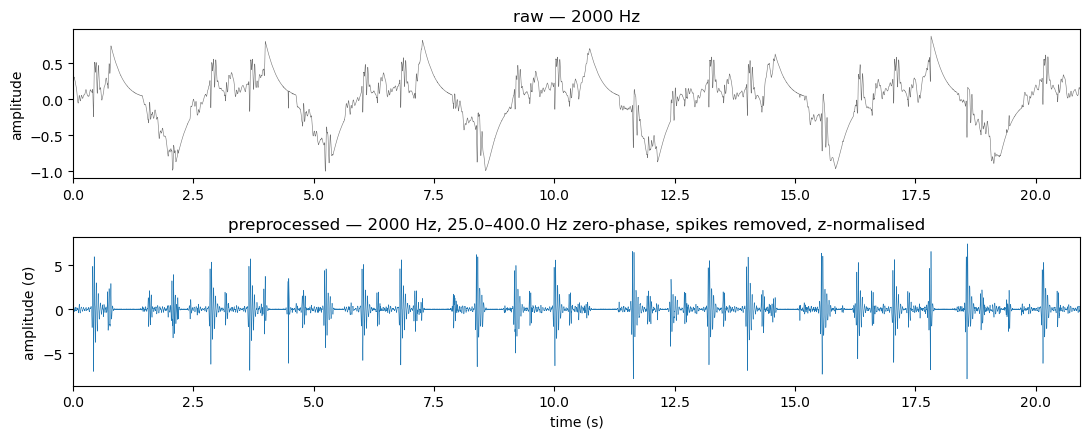

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 4.5), sharex=False)

t_raw = np.arange(len(raw)) / sr_in
axes[0].plot(t_raw, raw, lw=0.4, color="0.45")
axes[0].set_title(f"raw — {sr_in} Hz")
axes[0].set_ylabel("amplitude")

t_sig = np.arange(len(sig)) / SR
axes[1].plot(t_sig, sig, lw=0.4, color="C0")
axes[1].set_title(f"preprocessed — {SR} Hz, {cfg['preprocessing']['bandpass_low']}–"
                  f"{cfg['preprocessing']['bandpass_high']} Hz zero-phase, spikes removed, z-normalised")
axes[1].set_ylabel("amplitude (σ)")
axes[1].set_xlabel("time (s)")

for ax in axes:
    ax.margins(x=0)
fig.tight_layout()

The lower trace has mean 0 and standard deviation 1 by construction. That
removes **gain**, which is a property of the clinic's preamplifier rather than
of the patient — and since equipment correlates with site, and site correlates
with prevalence, absolute level would otherwise be a shortcut.

## 3. Cut into windows

Fixed 3-second windows. At 60–100 bpm each contains at least three complete
cardiac cycles, so a window sees essentially the same evidence the whole
recording does.

We use the **evaluation** hop (non-overlapping) rather than the training hop,
since we are inspecting rather than augmenting.

In [23]:
seg_cfg = cfg["segmentation"]
segments, seg_meta = segment_signal(
    sig, sr=SR,
    segment_seconds=seg_cfg["segment_seconds"],
    hop_seconds=seg_cfg["segment_seconds"],      # no overlap
    pad_policy=seg_cfg.get("pad_policy", "drop"),
)

print(f"{len(segments)} windows of {segments.shape[1]} samples "
      f"({seg_cfg['segment_seconds']} s each)")

W = 1                                   # <-- window to inspect
window = segments[W]
print(f"inspecting window {W}: {seg_meta[W]['start_s']:.1f}–{seg_meta[W]['end_s']:.1f} s")

6 windows of 6000 samples (3.0 s each)
inspecting window 1: 3.0–6.0 s


## 4. log-Mel — the representation that keeps time

Power spectrogram → mel filterbank → log. It stops before the DCT and before
any pooling, so the output stays a 2-D map with **both axes intact**.

In [24]:
%pip install librosa
logmel_ex = LogMelExtractor(SR, cfg)
logmel = logmel_ex.transform(window)

print(f"output shape {logmel.shape}  =  (n_mels, n_frames)  =  {np.prod(logmel.shape)} numbers")

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.

output shape (32, 188)  =  (n_mels, n_frames)  =  6016 numbers


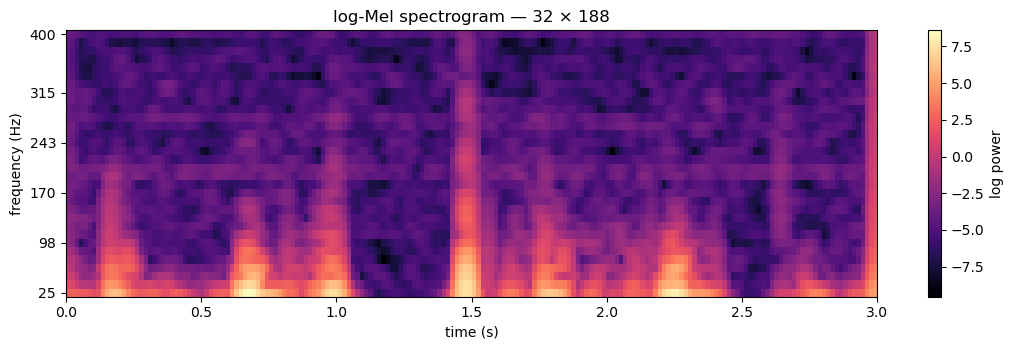

In [25]:
import librosa

mel_hz = librosa.mel_frequencies(n_mels=FEAT["n_mels"], fmin=FEAT["fmin"], fmax=FEAT["fmax"])
dur = seg_cfg["segment_seconds"]

fig, ax = plt.subplots(figsize=(11, 3.6))
im = ax.imshow(logmel, origin="lower", aspect="auto", cmap="magma",
               extent=[0, dur, 0, FEAT["n_mels"]])
ticks = np.linspace(0, FEAT["n_mels"] - 1, 6).astype(int)
ax.set_yticks(ticks + 0.5)
ax.set_yticklabels([f"{mel_hz[i]:.0f}" for i in ticks])
ax.set_ylabel("frequency (Hz)")
ax.set_xlabel("time (s)")
ax.set_title(f"log-Mel spectrogram — {logmel.shape[0]} × {logmel.shape[1]}")
fig.colorbar(im, ax=ax, label="log power")
fig.tight_layout()

The vertical stripes are S1 and S2: brief, low-frequency, high-energy events.
The intervals between them are where a murmur would appear as broadband noise.

**This is the only representation in which those events remain localised in
time.** The CNN receives this map directly.

## 5. MFCC — cepstrum, deltas, and what pooling destroys

Same front end up to the log, then a **DCT** (decorrelating the overlapping mel
bands and compacting energy into the first few coefficients), then **statistical
pooling** over time.

In [26]:
mfcc_ex = MFCCExtractor(SR, cfg)

mfcc_mat = mfcc_ex._mfcc_matrix(window)                       # (n_mfcc, n_frames)
d1 = librosa.feature.delta(mfcc_mat, width=mfcc_ex.delta_width, order=1)
d2 = librosa.feature.delta(mfcc_mat, width=mfcc_ex.delta_width, order=2)

mfcc_vec = mfcc_ex.transform(window)                          # pooled, final

print(f"per-frame matrix : {mfcc_mat.shape}")
print(f"with Δ and Δ²    : {mfcc_mat.shape[0]}×3 = {mfcc_mat.shape[0]*3} trajectories × {mfcc_mat.shape[1]} frames")
print(f"after pooling    : {mfcc_vec.shape[0]} dimensions"
      f"   ({mfcc_ex.n_mfcc} × {mfcc_ex.n_streams} × {len(mfcc_ex.aggregations)})")

per-frame matrix : (13, 188)
with Δ and Δ²    : 13×3 = 39 trajectories × 188 frames
after pooling    : 234 dimensions   (13 × 3 × 6)


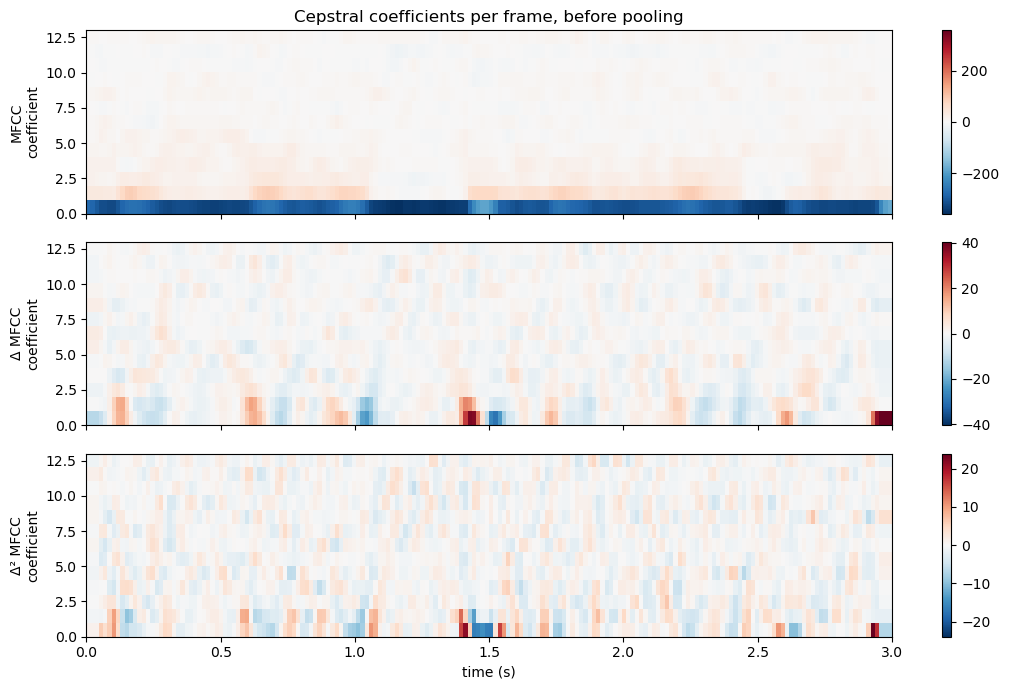

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)

for ax, M, name in zip(axes, [mfcc_mat, d1, d2], ["MFCC", "Δ MFCC", "Δ² MFCC"]):
    v = np.abs(M).max()
    im = ax.imshow(M, origin="lower", aspect="auto", cmap="RdBu_r",
                   vmin=-v, vmax=v, extent=[0, dur, 0, M.shape[0]])
    ax.set_ylabel(f"{name}\ncoefficient")
    fig.colorbar(im, ax=ax)

axes[-1].set_xlabel("time (s)")
axes[0].set_title("Cepstral coefficients per frame, before pooling")
fig.tight_layout()

Coefficient 0 tracks overall energy — you can see S1 and S2 in it. Higher
coefficients describe progressively finer wiggles in the spectral envelope. The
Δ panels respond to *change*, which is why they light up at the onsets.

### What pooling costs

Each of the 39 trajectories above is collapsed to six numbers: mean, std, min,
max, skewness, kurtosis. Those six are **unchanged if you shuffle the frames**.

In [39]:
from src.features.base import aggregate_over_time

# Shuffle the FRAMES of the cepstral matrix directly, then pool.
# Order-free statistics (mean, std, min, max, skew, kurtosis) see an unordered
# SET of frame values, so they are identical after any permutation.
rng = np.random.default_rng(0)
perm = rng.permutation(mfcc_mat.shape[1])
mfcc_shuf = mfcc_mat[:, perm]

# static stream only (no deltas -> no cross-frame neighbours to disturb)
aggs = mfcc_ex.aggregations
v_orig = aggregate_over_time(mfcc_mat,  aggs)
v_shuf = aggregate_over_time(mfcc_shuf, aggs)

print(f"static-stream pooled vector, {v_orig.size} dims")
print(f"max |Δ| after shuffling frames: {np.abs(v_orig - v_shuf).max():.2e}")
print(f"correlation: {np.corrcoef(v_orig, v_shuf)[0,1]:.6f}")
print("\n-> bit-identical: pooling sees an unordered set, order gone")

# The deltas are the ONLY reason the full vector is not perfectly invariant:
# Δ needs frame neighbours, so shuffling changes them.
d1_orig = librosa.feature.delta(mfcc_mat,  width=mfcc_ex.delta_width, order=1)
d1_shuf = librosa.feature.delta(mfcc_shuf, width=mfcc_ex.delta_width, order=1)
vd_orig = aggregate_over_time(d1_orig, aggs)
vd_shuf = aggregate_over_time(d1_shuf, aggs)
print(f"\nΔ-stream after shuffle: corr {np.corrcoef(vd_orig, vd_shuf)[0,1]:.3f}  (changes, as expected)")

static-stream pooled vector, 78 dims
max |Δ| after shuffling frames: 1.14e-05
correlation: 1.000000

-> bit-identical: pooling sees an unordered set, order gone

Δ-stream after shuffle: corr 0.987  (changes, as expected)


The static coefficients pool to a **bit-identical** vector after shuffling —
mean, std, min, max, skewness and kurtosis all see an unordered set of frame
values. Only the Δ streams change, because a derivative needs frame neighbours.

That near-total invariance is what "the time axis is discarded" means. A
systolic murmur and a diastolic one with the same spectral content would produce
essentially the same MFCC vector.

## 6. PWP — wavelet packet bands and their descriptors

A level-6 Daubechies-4 packet tree gives 2⁶ = 64 uniform subbands, which are
merged into perceptually spaced bands. Each band is summarised by seven
descriptors.

Unlike the STFT, the packet transform tiles the time–frequency plane adaptively,
which is the motivation: cardiac events are transients, and the STFT's
local-stationarity assumption fits them poorly.

In [30]:
pwp_ex = PWPExtractor(SR, cfg)
pwp_vec = pwp_ex.transform(window)

print(f"wavelet          {pwp_ex.wavelet}, level {pwp_ex.level}")
print(f"nodes            {pwp_ex.n_nodes} of width {pwp_ex.node_width_hz:.1f} Hz")
print(f"kept in band     {len(pwp_ex.kept_nodes)}")
print(f"perceptual bands {pwp_ex.n_bands}")
print(f"descriptors      {pwp_ex.descriptors}")
print(f"output           {pwp_ex.n_bands} × {len(pwp_ex.descriptors)} = {pwp_vec.shape[0]} dimensions")
print(f"\nnode order       '{pwp_ex.node_order}'  <- must be 'freq'; pywt's default")
print( "                 Paley order is a bit-reversed permutation of frequency order")

wavelet          db4, level 6
nodes            64 of width 15.6 Hz
kept in band     25
perceptual bands 12
descriptors      ['log_energy', 'rel_energy', 'shannon_entropy', 'std', 'skew', 'kurtosis', 'max_abs']
output           12 × 7 = 84 dimensions

node order       'freq'  <- must be 'freq'; pywt's default
                 Paley order is a bit-reversed permutation of frequency order


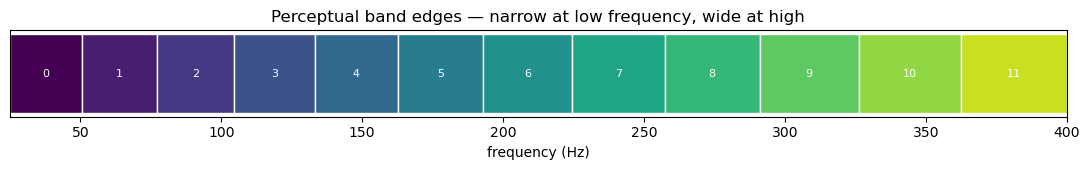

In [31]:
edges = pwp_ex.band_edges
fig, ax = plt.subplots(figsize=(11, 1.8))
for b in range(pwp_ex.n_bands):
    ax.barh(0, edges[b+1] - edges[b], left=edges[b], height=0.6,
            edgecolor="white", color=plt.cm.viridis(b / pwp_ex.n_bands))
    ax.text((edges[b] + edges[b+1]) / 2, 0, str(b), ha="center", va="center",
            fontsize=8, color="white")
ax.set_xlim(edges[0], edges[-1])
ax.set_yticks([])
ax.set_xlabel("frequency (Hz)")
ax.set_title("Perceptual band edges — narrow at low frequency, wide at high")
fig.tight_layout()

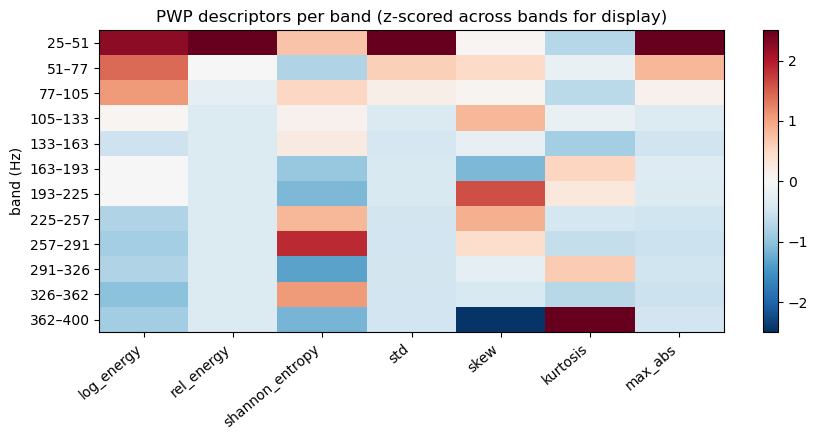

In [32]:
D = pwp_vec.reshape(pwp_ex.n_bands, len(pwp_ex.descriptors))

fig, ax = plt.subplots(figsize=(9, 4.5))
Dn = (D - D.mean(axis=0)) / (D.std(axis=0) + 1e-9)      # per-descriptor z, for display only
im = ax.imshow(Dn, aspect="auto", cmap="RdBu_r", vmin=-2.5, vmax=2.5)
ax.set_xticks(range(len(pwp_ex.descriptors)))
ax.set_xticklabels(pwp_ex.descriptors, rotation=40, ha="right")
ax.set_yticks(range(pwp_ex.n_bands))
ax.set_yticklabels([f"{edges[b]:.0f}–{edges[b+1]:.0f}" for b in range(pwp_ex.n_bands)])
ax.set_ylabel("band (Hz)")
ax.set_title("PWP descriptors per band (z-scored across bands for display)")
fig.colorbar(im, ax=ax)
fig.tight_layout()

Two descriptors carry most of the interpretive weight in the report's SHAP
analysis:

- **Shannon entropy** — high when energy is spread within the band (noise-like,
  i.e. murmur), low when concentrated (tonal, i.e. S1/S2).
- **Kurtosis** — the fourth moment, so it is dominated by extreme values. High
  for impulsive transients, near 3 for continuous noise.

Together they separate *impulsive and tonal* from *sustained and noisy*, which
is roughly the S1/S2 versus murmur distinction.

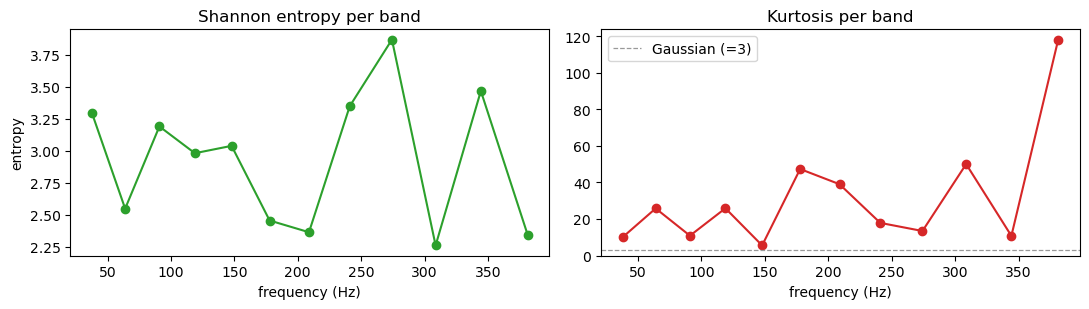

In [33]:
if "shannon_entropy" in pwp_ex.descriptors and "kurtosis" in pwp_ex.descriptors:
    centres = 0.5 * (edges[:-1] + edges[1:])
    ie = pwp_ex.descriptors.index("shannon_entropy")
    ik = pwp_ex.descriptors.index("kurtosis")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
    axes[0].plot(centres, D[:, ie], "o-", color="C2")
    axes[0].set_title("Shannon entropy per band"); axes[0].set_ylabel("entropy")
    axes[1].plot(centres, D[:, ik], "o-", color="C3")
    axes[1].axhline(3, color="0.6", ls="--", lw=0.9, label="Gaussian (=3)")
    axes[1].set_title("Kurtosis per band"); axes[1].legend()
    for ax in axes:
        ax.set_xlabel("frequency (Hz)")
    fig.tight_layout()
else:
    print("descriptors configured differently:", pwp_ex.descriptors)

## 7. All three, side by side

The same 3 seconds of audio, described three ways.

Text(0.5, 0.99, 'training-e/e00001, window 1')

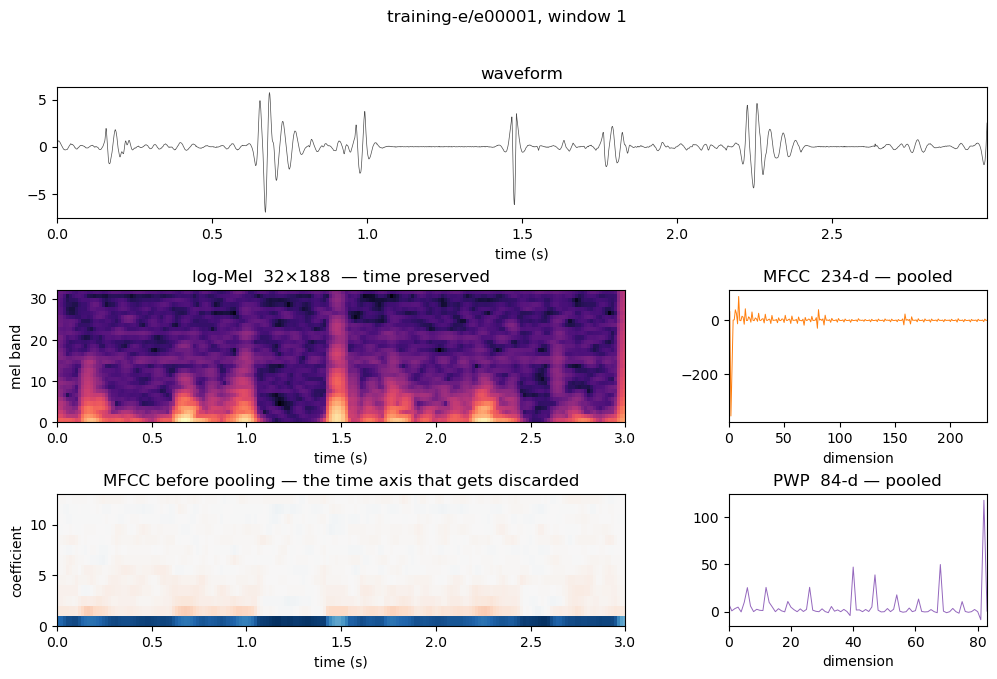

In [34]:
fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(3, 2, width_ratios=[2.2, 1], hspace=0.55, wspace=0.25)

ax = fig.add_subplot(gs[0, :])
ax.plot(np.arange(len(window)) / SR, window, lw=0.5, color="0.3")
ax.set_title("waveform"); ax.set_xlabel("time (s)"); ax.margins(x=0)

ax = fig.add_subplot(gs[1, 0])
ax.imshow(logmel, origin="lower", aspect="auto", cmap="magma", extent=[0, dur, 0, FEAT["n_mels"]])
ax.set_title(f"log-Mel  {logmel.shape[0]}×{logmel.shape[1]}  — time preserved")
ax.set_xlabel("time (s)"); ax.set_ylabel("mel band")

ax = fig.add_subplot(gs[1, 1])
ax.plot(mfcc_vec, lw=0.7, color="C1"); ax.margins(x=0)
ax.set_title(f"MFCC  {mfcc_vec.shape[0]}-d — pooled")
ax.set_xlabel("dimension")

ax = fig.add_subplot(gs[2, 0])
v = np.abs(mfcc_mat).max()
ax.imshow(mfcc_mat, origin="lower", aspect="auto", cmap="RdBu_r", vmin=-v, vmax=v, extent=[0, dur, 0, mfcc_mat.shape[0]])
ax.set_title("MFCC before pooling — the time axis that gets discarded")
ax.set_xlabel("time (s)"); ax.set_ylabel("coefficient")

ax = fig.add_subplot(gs[2, 1])
ax.plot(pwp_vec, lw=0.7, color="C4"); ax.margins(x=0)
ax.set_title(f"PWP  {pwp_vec.shape[0]}-d — pooled")
ax.set_xlabel("dimension")

fig.suptitle(f"{WAV.parent.name}/{WAV.stem}, window {W}", y=0.99)

In [36]:
print(f"{'domain':<10}{'shape':>14}{'dimensions':>13}   time axis")
print("-" * 55)
print(f"{'MFCC':<10}{str(mfcc_vec.shape):>14}{mfcc_vec.size:>13}   discarded by pooling")
print(f"{'log-Mel':<10}{str(logmel.shape):>14}{logmel.size:>13}   preserved")
print(f"{'PWP':<10}{str(pwp_vec.shape):>14}{pwp_vec.size:>13}   discarded by pooling")

domain             shape   dimensions   time axis
-------------------------------------------------------
MFCC              (234,)          234   discarded by pooling
log-Mel        (32, 188)         6016   preserved
PWP                (84,)           84   discarded by pooling


## 8. Cardiac-cycle context

The segmenter used in the explainability analysis. It runs **independently of
any model** and only at evaluation time, so it cannot manufacture a positive
alignment result.

In [37]:
seg = segment_cardiac_cycle(window, SR, cfg)

print(f"heart rate   {seg['heart_rate_bpm']:.0f} bpm")
print(f"confidence   {seg['confidence']:.2f}   usable: {seg['usable']}")
print("\ntime fractions per state:")
for name, frac in seg["state_fractions"].items():
    print(f"  {name:<10}{frac:6.1%}")

heart rate   76 bpm
confidence   0.38   usable: False

time fractions per state:
  S1         12.0%
  systole    26.8%
  S2         16.0%
  diastole   41.1%
  unknown     4.0%


Those fractions are the null hypothesis for the enrichment metric. A model
attending uniformly over time scores exactly the time fraction of each state, so
"25 % of attribution in systole" is meaningless until you know systole occupies
about 23 % of the window.

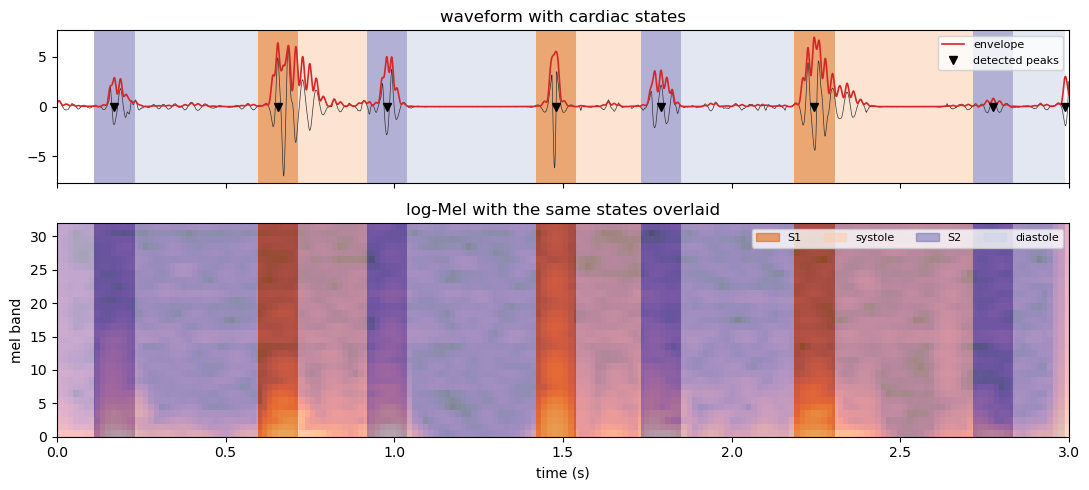

In [38]:
COLORS = {"S1": "#d95f02", "systole": "#fdcdac", "S2": "#7570b3", "diastole": "#cbd5e8", "unknown": "white"}

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.4]})

t = np.arange(len(window)) / SR
states = seg["states"]

for ax in axes:
    change = np.flatnonzero(np.diff(states)) + 1
    bounds = np.concatenate([[0], change, [len(states)]])
    for lo, hi in zip(bounds[:-1], bounds[1:]):
        ax.axvspan(t[lo], t[min(hi, len(t)-1)],
                   color=COLORS[STATE_NAMES[int(states[lo])]], alpha=0.55, lw=0)

axes[0].plot(t, window, lw=0.5, color="0.2")
axes[0].plot(t, seg["envelope"] / (seg["envelope"].max() + 1e-9) * np.abs(window).max(),
             lw=1.2, color="C3", label="envelope")
axes[0].plot(seg["peaks"] / SR, np.zeros(len(seg["peaks"])), "kv", ms=6, label="detected peaks")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("waveform with cardiac states")
axes[0].margins(x=0)

axes[1].imshow(logmel, origin="lower", aspect="auto", cmap="magma",
               extent=[0, dur, 0, FEAT["n_mels"]], alpha=0.85)
axes[1].set_title("log-Mel with the same states overlaid")
axes[1].set_xlabel("time (s)"); axes[1].set_ylabel("mel band")

handles = [plt.Rectangle((0,0),1,1, color=COLORS[s], alpha=0.55) for s in ["S1","systole","S2","diastole"]]
axes[1].legend(handles, ["S1","systole","S2","diastole"], loc="upper right", fontsize=8, ncol=4)
fig.tight_layout()

---

### What to take from this

- **log-Mel** keeps both axes, so the CNN can in principle learn that noise
  falls *between* two thumps rather than during one — which is the definition of
  a systolic murmur.
- **MFCC** and **PWP** summarise each window into an unordered set of statistics.
  They describe *what* frequencies are present, not *when*.
- In the report, MFCC nonetheless outperformed PWP under both classifier
  families, and the log-Mel CNN was statistically indistinguishable from
  SVM–MFCC on MAcc. Preserving the time axis bought no measurable accuracy here.

To inspect another recording, change `WAV`; to inspect another window, change `W`.